# Setup

## Imports

In [1]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from src.preprocessing import (
    filter_low_magnitude_genes,
    filter_high_apoptosis_cells,
    normalize_by_library_size,
    log_transform,
    normalize_data_with_pearson,
    genes,
    filter_doublets
)
from src.visualization import (
    plot_gene_magnitude_distribution,
    plot_normalization_comparison,
    plot_log_transform_comparison,
    plot_pearson_diagnostic,
    plot_metric_distribution,
    calculate_gene_fraction
)
from src.utils import extract_gene_subset

## Data Loading

In [3]:
from src.data_loading import load_csv_data

DATA_PATH = '../data/GSE36552/raw/GSE36552.count_matrix.csv.gz'
raw_data = load_csv_data(DATA_PATH)
raw_data = raw_data.T

raw_data.shape

(124, 20286)

# Gene Filtering

In [4]:
clean_data = filter_low_magnitude_genes(raw_data)

clean_data.head()

  • Dropped 317 low-magnitude genes


,FSTL1,AACS,RPS11,ELMO2,PNMA1,MMP2,SLMAP,TMEM216,SAMD4A,HAUS2,...,LCN1,IL17REL,GPX5,SPATA8,SNORA54,G6PC2,LOC440117,CCT8L2,CXorf66,SPRR3
GSM922271,245,628,21930,2,233,5,1340,297,1,1469,...,0,0,0,0,0,0,0,0,0,0
GSM922256,1629,1287,11959,17,48,26,1364,43,76,382,...,0,0,0,0,0,0,0,0,0,0
GSM922187,0,51,38556,40,3269,15,847,4,95,2474,...,0,0,0,0,0,0,0,0,0,0
GSM922199,14,18,7597,0,765,0,761,0,0,1075,...,0,0,0,0,0,0,0,0,0,0
GSM922150,0,825,84470,4182,205,0,114,340,2260,334,...,0,0,0,0,0,0,0,0,0,0


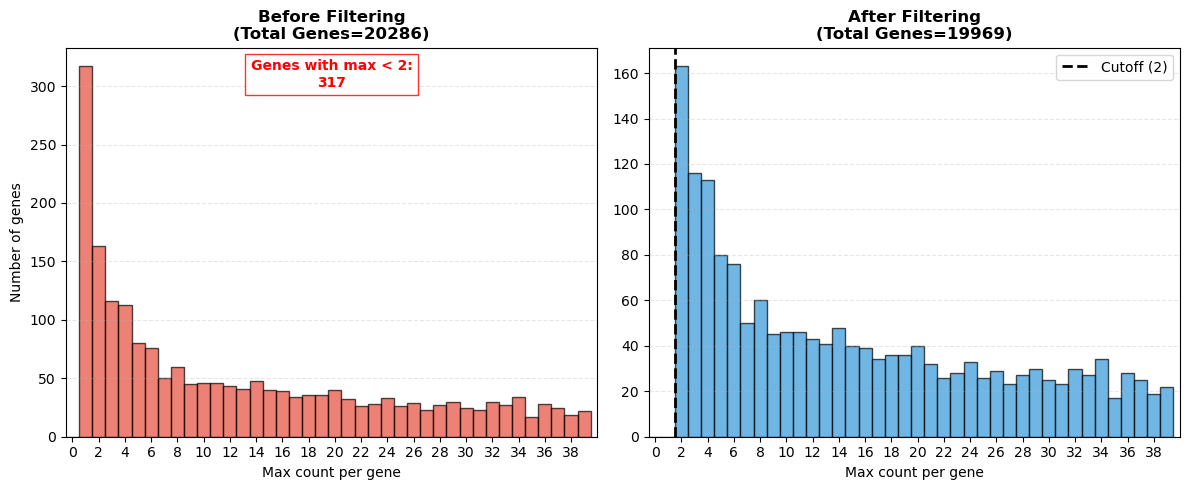

In [5]:
plot_gene_magnitude_distribution(raw_data, clean_data, x_limit=40)

# Quality Control (Cell Filtering)

## Mitochondrial

In [6]:
# Check if any starts with "MT-" (Human)
print("'MT-' genes:", clean_data.columns.str.startswith('MT-').sum())

'MT-' genes: 0


## Apoptosis

In [7]:
apoptosis_data = extract_gene_subset(clean_data, genes.HUMAN_APOPTOSIS_GENES, "Apoptosis")

Apoptosis: Matched 155 of 161 reference genes.


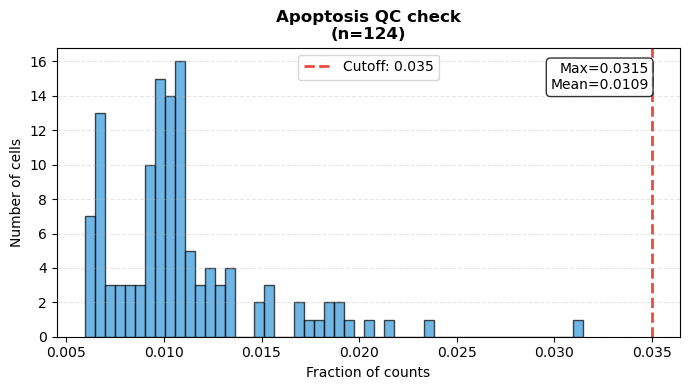

In [8]:
apoptosis_fractions = calculate_gene_fraction(clean_data, genes.HUMAN_APOPTOSIS_GENES)
plot_metric_distribution(apoptosis_fractions, title="Apoptosis QC check", cutoff=0.035)

## rRNA

In [9]:
rrna_data = extract_gene_subset(clean_data, genes.HUMAN_RRNA_GENES, "rRNA")

rRNA: Matched 0 of 552 reference genes.


## Doublets

In [10]:
no_doublets_data = filter_doublets(clean_data)

  • Dropped 12 doublets


# Normalization

## logCPM

### Normalize by library size

In [11]:
normalized_data = normalize_by_library_size(no_doublets_data)

normalized_data.shape

  • Normalizing library size (rescale=1e+06)


(112, 19969)

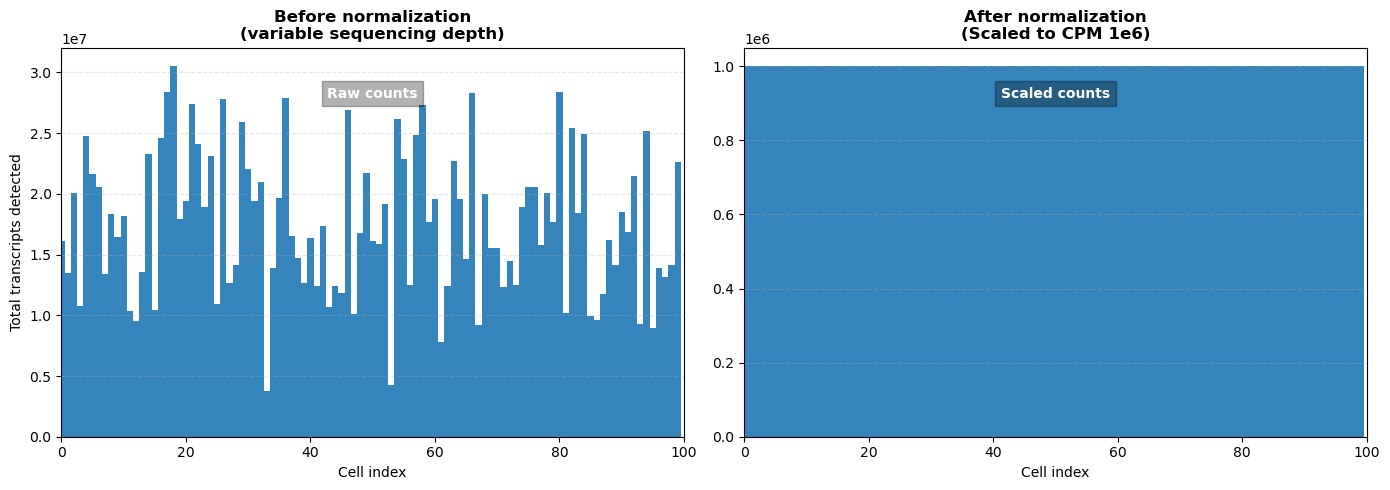

In [12]:
plot_normalization_comparison(no_doublets_data, normalized_data)

### Log Transform

In [13]:
logged_data = log_transform(normalized_data)

logged_data.shape

  • Applying log transform (log1+x)


(112, 19969)

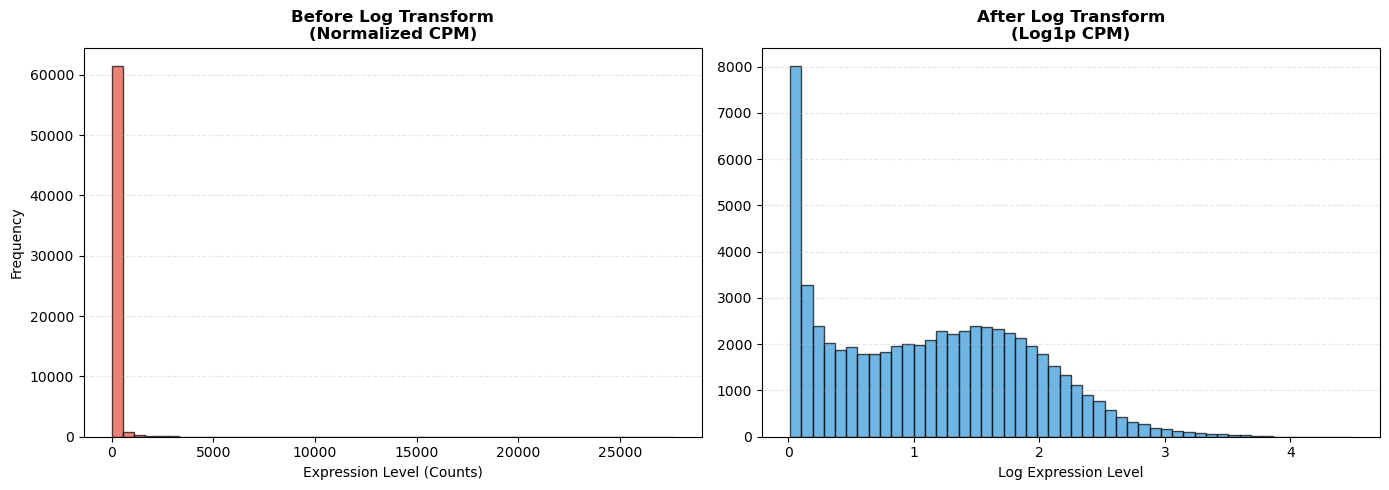

In [14]:
plot_log_transform_comparison(normalized_data, logged_data)

## Pearson residuals

In [15]:
pearsons_data = normalize_data_with_pearson(no_doublets_data)

pearsons_data.shape

  • Computing residuals for 112 cells
  • Selecting top 3000 variable genes


(112, 3000)

In [16]:
pearsons_data.head()

,FSTL1,AACS,ELMO2,SAMD4A,ZHX3,GCSH,MTERF,PDCL3,CLK4,SALL1,...,DCHS2,PPP2R2C,MYH15,NELL1,PLCL1,BICC1,TGFA,CCDC121,DCC,TP63
GSM922271,-1.656533,7.788945,-9.419921,-8.615447,-9.502446,6.232974,10.583005,-9.044159,-9.195291,-6.281201,...,-7.448870,-7.427344,-8.760528,-8.173205,-9.132508,-7.383698,-7.701544,-7.795373,-7.425065,-8.255957
GSM922256,10.583005,10.583005,-9.197903,-6.206477,-9.587419,7.506291,10.583005,-9.727892,-3.602048,-2.402313,...,-7.332052,-7.310045,-8.687947,-8.077039,-9.078310,-7.265447,-7.590928,-7.687327,-7.307716,-8.162727
GSM922187,-8.952879,-7.994531,-9.224596,-6.780034,-9.167586,-5.130470,10.583005,6.727020,-4.341437,-0.282640,...,-7.901730,-7.882448,-9.026965,-8.535250,-9.328180,-7.843273,-8.126106,-8.208506,-7.880406,-8.605725
GSM922199,-7.906639,-7.927750,-9.309836,-8.368308,-7.685507,10.583005,-7.560750,10.583005,-2.331745,-6.250818,...,-7.043941,-7.020915,-8.501822,-7.834945,-8.937561,-6.974307,-7.316229,-7.418307,-7.018479,-7.927440
GSM922150,-9.402664,-0.142720,9.934036,10.583005,10.583005,-9.434930,-7.665764,-7.223123,-9.570729,-8.194695,...,10.583005,10.583005,4.610966,10.583005,5.106338,10.583005,10.583005,6.789079,10.583005,10.583005
